# A 512-unit layer has room for thousands of features

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Room for more directions than dimensions

In [1]:
import numpy as np

rng = np.random.default_rng(0)
d = 512
print(f"1/sqrt(d) = {1/np.sqrt(d):.4f}")
for n in (512, 3000, 10000):
    F = rng.standard_normal((n, d))
    F /= np.linalg.norm(F, axis=1, keepdims=True)   # n random unit vectors
    total, top, over = 0.0, 0.0, 0
    for s in range(0, n, 1000):                     # row blocks save memory
        C = np.abs(F[s:s + 1000] @ F.T)
        C = C[np.arange(C.shape[0])[:, None] + s < np.arange(n)]  # i < j
        total, top, over = total + C.sum(), max(top, C.max()), over + (C > 0.25).sum()
    pairs = n * (n - 1) // 2
    print(f"n={n:6,d}  mean|cos| {total / pairs:.4f}  max|cos| {top:.3f}  "
          f"pairs above 0.25: {over} of {pairs:,}")

1/sqrt(d) = 0.0442
n=   512  mean|cos| 0.0353  max|cos| 0.191  pairs above 0.25: 0 of 130,816


n= 3,000  mean|cos| 0.0353  max|cos| 0.238  pairs above 0.25: 0 of 4,498,500


n=10,000  mean|cos| 0.0353  max|cos| 0.242  pairs above 0.25: 0 of 49,995,000


## A toy model that chooses to superpose

In [2]:
def train_toy(n=20, m=5, sparsity=0.0, steps=4000, batch=512, lr=1e-2, seed=0):
    rng = np.random.default_rng(seed)
    imp = 0.9 ** np.arange(n)                      # feature importance
    W = rng.standard_normal((m, n)) * 0.3
    b = np.zeros(n)
    mo = [np.zeros_like(W), np.zeros_like(b)]; ve = [np.zeros_like(W), np.zeros_like(b)]
    for t in range(1, steps + 1):
        x = rng.random((batch, n)) * (rng.random((batch, n)) > sparsity)
        h = x @ W.T                                 # compress: n -> m
        pre = h @ W + b                             # expand: m -> n
        g = 2 * imp * (np.maximum(pre, 0) - x) * (pre > 0) / batch
        gW = h.T @ g + (g @ W.T).T @ x              # both uses of W
        for p, gr, mm, vv in zip((W, b), (gW, g.sum(0)), mo, ve):   # Adam
            mm[:] = 0.9 * mm + 0.1 * gr; vv[:] = 0.999 * vv + 0.001 * gr**2
            p -= lr * (mm / (1 - 0.9**t)) / (np.sqrt(vv / (1 - 0.999**t)) + 1e-8)
    return W, b

for S in (0.0, 0.7, 0.9, 0.97):
    W, b = train_toy(sparsity=S)
    norms = np.linalg.norm(W, axis=0)
    live = norms > 0.5                              # features the model kept
    U = W[:, live] / norms[live]
    cos = (U.T @ U)[np.triu_indices(live.sum(), 1)] # pairwise, i < j
    print(f"S={S:.2f}  stored {live.sum():2d} of 20 in 5 dims  "
          f"max cos {cos.max(initial=0):+.2f}  antipodal {(cos < -0.9).sum()}  bias {b[live].mean():+.2f}")

S=0.00  stored  5 of 20 in 5 dims  max cos +0.00  antipodal 0  bias +0.02


S=0.70  stored 10 of 20 in 5 dims  max cos +0.02  antipodal 5  bias +0.02


S=0.90  stored 13 of 20 in 5 dims  max cos +0.38  antipodal 1  bias -0.16


S=0.97  stored 16 of 20 in 5 dims  max cos +0.27  antipodal 0  bias -0.23


## Pulling features back out with a sparse autoencoder

In [3]:
def train_sae(lam, m=32, steps=1500, batch=256, lr=3e-3, seed=1):
    rng = np.random.default_rng(seed)
    D = rng.standard_normal((5, m)); D /= np.linalg.norm(D, axis=0)   # decoder, unit columns
    E, c = D.T.copy(), np.zeros(m)                                    # encoder starts at D^T
    P = [D, E, c]; mo = [np.zeros_like(p) for p in P]; ve = [np.zeros_like(p) for p in P]
    for t in range(1, steps + 1):
        a = (rng.random((batch, 20)) * (rng.random((batch, 20)) > 0.97)) @ W.T
        z = a @ E.T + c; h = np.maximum(z, 0)                         # ReLU encoder
        err = h @ D.T - a
        gz = (err @ D + lam) * (z > 0) / batch        # grad of 0.5|err|^2 + lam*sum(h)
        for p, g, mm, vv in zip(P, (err.T @ h / batch, gz.T @ a, gz.sum(0)), mo, ve):
            mm[:] = 0.9 * mm + 0.1 * g; vv[:] = 0.999 * vv + 0.001 * g**2
            p -= lr * (mm / (1 - 0.9**t)) / (np.sqrt(vv / (1 - 0.999**t)) + 1e-8)
        D /= np.linalg.norm(D, axis=0)                                # renormalize columns
    return D, E, c

truth = W[:, live] / norms[live]                      # the 16 stored feature directions
a = (rng.random((20000, 20)) * (rng.random((20000, 20)) > 0.97)) @ W.T   # held out
for lam in (0.01, 0.03, 0.1):
    D, E, c = train_sae(lam)
    cos = truth.T @ D; best = cos.max(1)               # best latent per true feature
    hits = len(set(cos.argmax(1)[best > 0.9]))         # distinct latents matched
    rel = np.linalg.norm(np.maximum(a @ E.T + c, 0) @ D.T - a) / np.linalg.norm(a)
    print(f"lambda {lam:.2f}  matched at cos > 0.9: {(best > 0.9).sum():2d} of {live.sum()} "
          f"({hits} distinct latents)  reconstruction error {rel:.2f}")

lambda 0.01  matched at cos > 0.9:  2 of 16 (2 distinct latents)  reconstruction error 0.09


lambda 0.03  matched at cos > 0.9:  6 of 16 (6 distinct latents)  reconstruction error 0.14


lambda 0.10  matched at cos > 0.9: 16 of 16 (16 distinct latents)  reconstruction error 0.31


## The figure

In [4]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

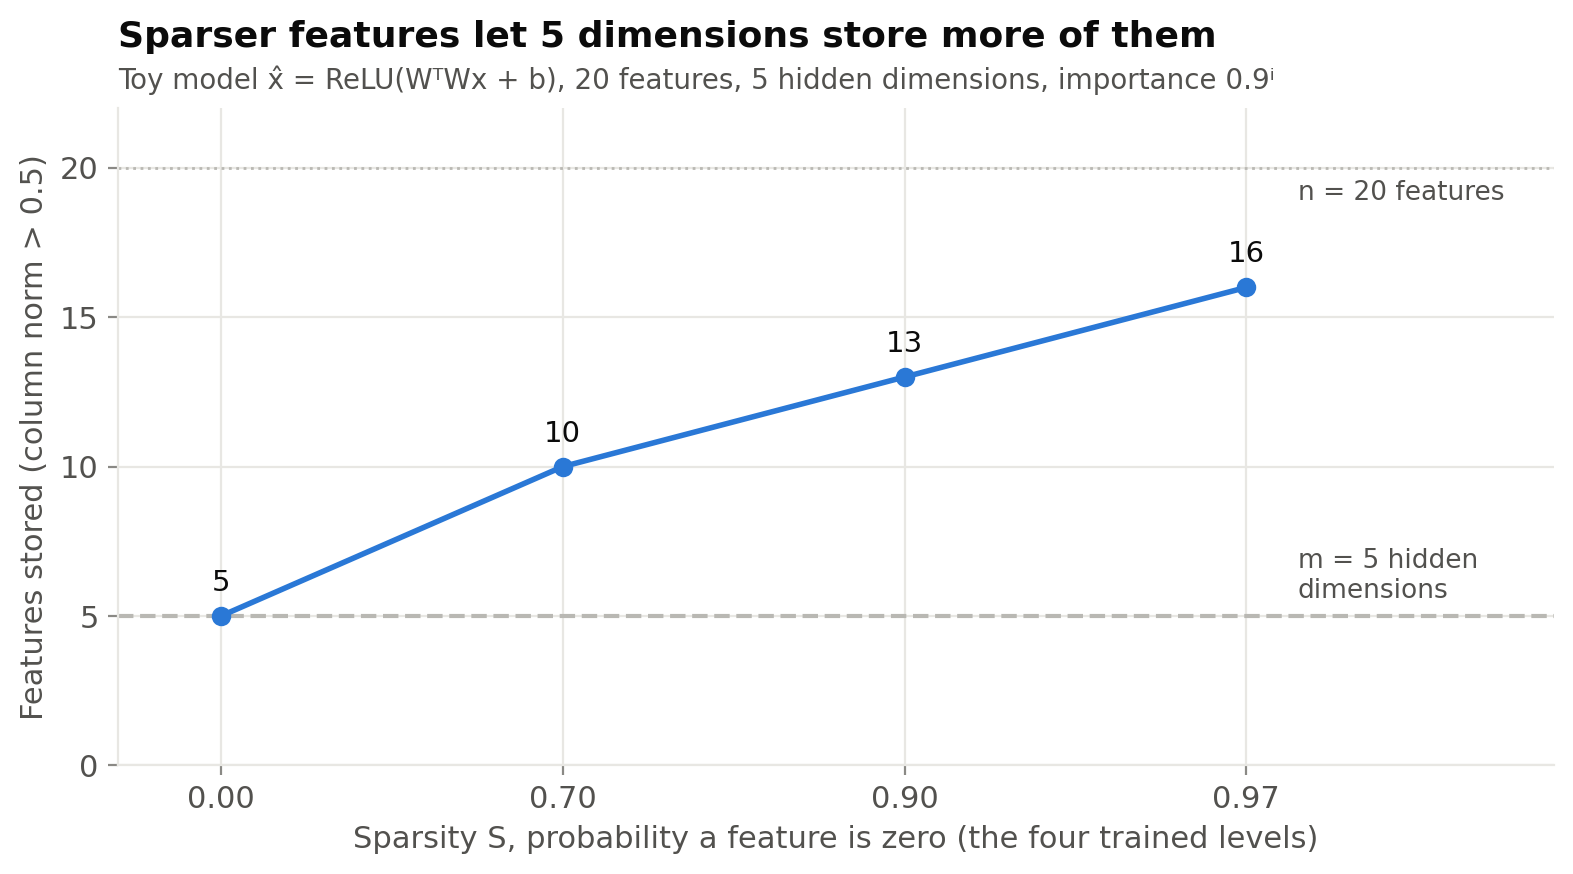

In [5]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # The article's toy model (n = 20 features, m = 5 dims), same code and seeds
    def train_toy(n=20, m=5, sparsity=0.0, steps=4000, batch=512, lr=1e-2, seed=0):
        rng = np.random.default_rng(seed)
        imp = 0.9 ** np.arange(n)
        W = rng.standard_normal((m, n)) * 0.3
        b = np.zeros(n)
        mo = [np.zeros_like(W), np.zeros_like(b)]; ve = [np.zeros_like(W), np.zeros_like(b)]
        for t in range(1, steps + 1):
            x = rng.random((batch, n)) * (rng.random((batch, n)) > sparsity)
            h = x @ W.T
            pre = h @ W + b
            g = 2 * imp * (np.maximum(pre, 0) - x) * (pre > 0) / batch
            gW = h.T @ g + (g @ W.T).T @ x
            for p, gr, mm, vv in zip((W, b), (gW, g.sum(0)), mo, ve):
                mm[:] = 0.9 * mm + 0.1 * gr; vv[:] = 0.999 * vv + 0.001 * gr**2
                p -= lr * (mm / (1 - 0.9**t)) / (np.sqrt(vv / (1 - 0.999**t)) + 1e-8)
        return W, b

    S = [0.0, 0.7, 0.9, 0.97]
    stored = [int((np.linalg.norm(train_toy(sparsity=s)[0], axis=0) > 0.5).sum()) for s in S]
    print(stored)

    f, ax = fig()
    x = np.arange(len(S))
    ax.axhline(5, color=NEUTRAL, lw=1.5, ls="--")
    ax.text(3.15, 5.4, "m = 5 hidden\ndimensions", color=INK_2, fontsize=9.5, va="bottom")
    ax.axhline(20, color=NEUTRAL, lw=1.0, ls=":")
    ax.text(3.15, 19.6, "n = 20 features", color=INK_2, fontsize=9.5, va="top")
    ax.plot(x, stored, color=S1, marker="o")
    for xi, k in zip(x, stored):
        ax.annotate(f"{k}", (xi, k), xytext=(0, 9), textcoords="offset points",
                    ha="center", color=INK, fontsize=10.5)
    ax.set_xticks(x, [f"{s:.2f}" for s in S])
    ax.set_xlim(-0.3, 3.9); ax.set_ylim(0, 22)
    ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_xlabel("Sparsity S, probability a feature is zero (the four trained levels)")
    ax.set_ylabel("Features stored (column norm > 0.5)")
    ax.set_title("Sparser features let 5 dimensions store more of them")
    subtitle(ax, "Toy model x̂ = ReLU(WᵀWx + b), 20 features, 5 hidden dimensions, importance 0.9ⁱ")
    path = pathlib.Path(__file__).parent / "09-toy-superposition.png"
    save(f, path)
import matplotlib.pyplot as plt
plt.show()